Initialize all the import

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Number of rows and columns,
Which columns are numeric,
Which columns are categorical,
Any columns with incorrect data types.

In [5]:
df = pd.read_csv("employee_data.csv")
df.head()

,Employee_ID,Age,Gender,Department,Experience,Salary,Performance_Score
0,101,25,Male,HR,2.0,25000.0,7.0
1,102,28,Female,IT,4.0,35000.0,8.0
2,103,30,Male,Finance,5.0,42000.0,9.0
3,104,27,Female,IT,3.0,32000.0,7.0
4,105,35,Male,Sales,8.0,55000.0,8.0


In [6]:
df.shape

(26, 7)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        26 non-null     int64  
 1   Age                26 non-null     str    
 2   Gender             26 non-null     str    
 3   Department         26 non-null     str    
 4   Experience         25 non-null     float64
 5   Salary             25 non-null     float64
 6   Performance_Score  25 non-null     float64
dtypes: float64(3), int64(1), str(3)
memory usage: 1.6 KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Employee_ID,26.0,113.269231,7.340614,101.0,107.25,113.5,119.75,125.0
Experience,25.0,7.480000,4.942334,1.0,4.00,6.0,10.00,20.0
Salary,25.0,55000.000000,24684.678109,22000.0,38000.00,50000.0,65000.00,120000.0
Performance_Score,25.0,8.000000,1.118034,6.0,7.00,8.0,9.00,10.0


In [9]:
df.dtypes

Employee_ID            int64
Age                      str
Gender                   str
Department               str
Experience           float64
Salary               float64
Performance_Score    float64
dtype: object

Explaining how many duplicates were removed

In [10]:
df.duplicated().sum()

np.int64(1)

In [11]:
df=df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

Identifying columns with missing values

In [33]:
df.isnull().sum()

Employee_ID          0
Age                  0
Gender               0
Department           0
Experience           0
Salary               0
Performance_Score    0
dtype: int64

In [34]:
(df.isnull().sum()/len(df))*100

Employee_ID          0.0
Age                  0.0
Gender               0.0
Department           0.0
Experience           0.0
Salary               0.0
Performance_Score    0.0
dtype: float64

In [13]:
for col in df.columns:
    print(col,df[col].dtype)

Employee_ID int64
Age str
Gender str
Department str
Experience float64
Salary float64
Performance_Score float64


Conversions performed

In [17]:
df['Salary'] = pd.to_numeric(df['Salary'],errors='coerce')

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 25 entries, 0 to 25
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        25 non-null     int64  
 1   Age                25 non-null     str    
 2   Gender             25 non-null     str    
 3   Department         25 non-null     str    
 4   Experience         24 non-null     float64
 5   Salary             24 non-null     float64
 6   Performance_Score  24 non-null     float64
dtypes: float64(3), int64(1), str(3)
memory usage: 1.6 KB


Explaining why median and mode wear used

In [21]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [22]:
cat_cols = df.select_dtypes(include=['object','string']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [23]:
df.isnull().sum()

Employee_ID          0
Age                  0
Gender               0
Department           0
Experience           0
Salary               0
Performance_Score    0
dtype: int64

Mention positively or Negatively skewed columns

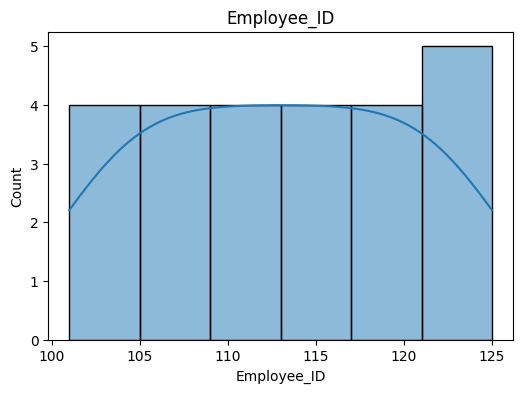

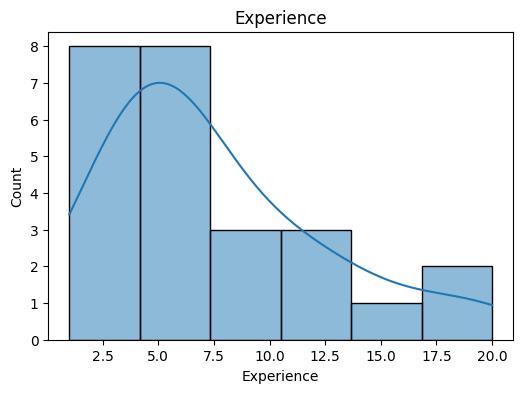

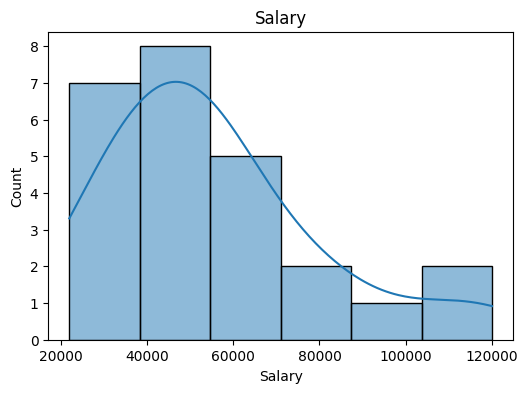

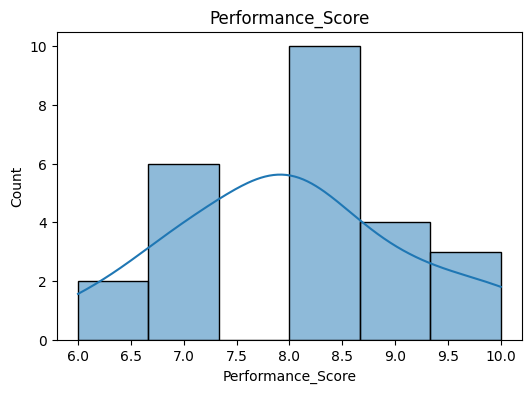

In [24]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [25]:
df[num_cols].skew()

Employee_ID          0.000000
Experience           1.123873
Salary               1.167968
Performance_Score    0.194441
dtype: float64

Which columns have outliers,
Are they severe or moderate

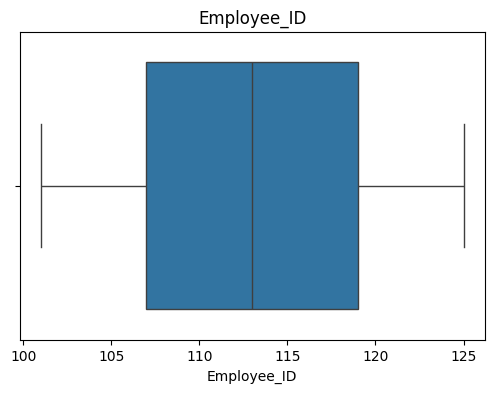

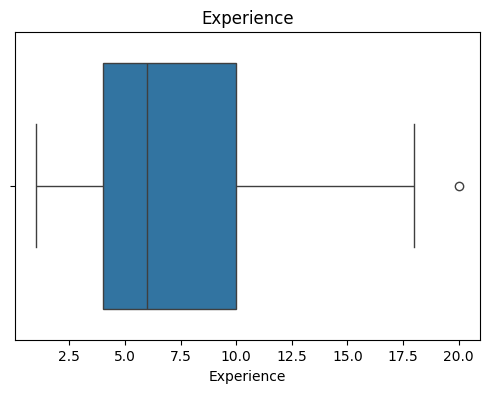

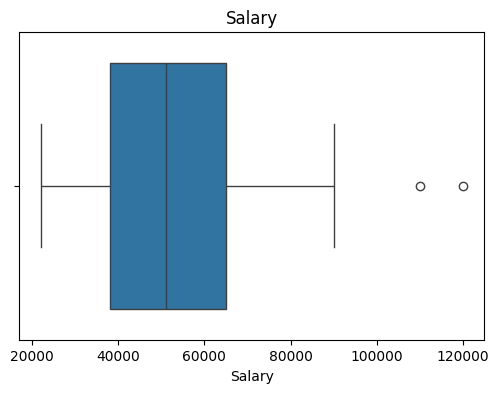

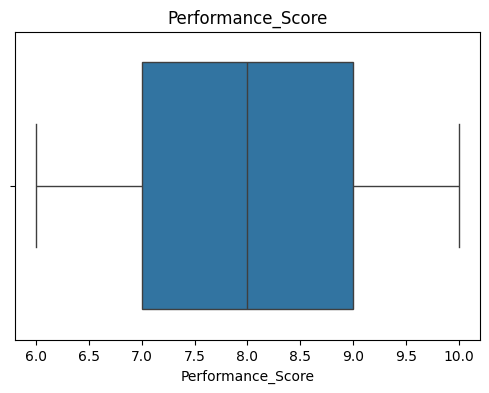

In [26]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Relationships between variables

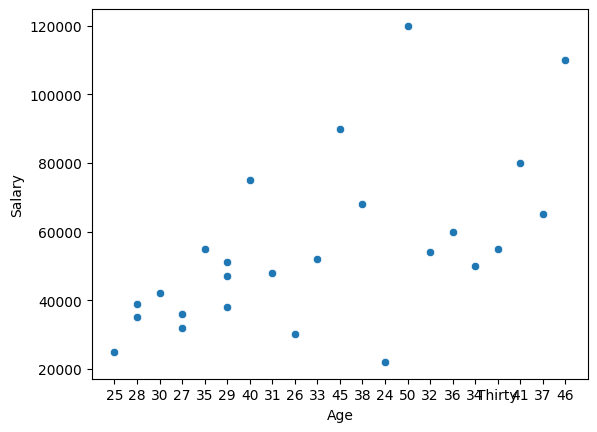

In [27]:
sns.scatterplot(data=df, x='Age', y='Salary')
plt.show()

Highly correlated features,weakly correlated features

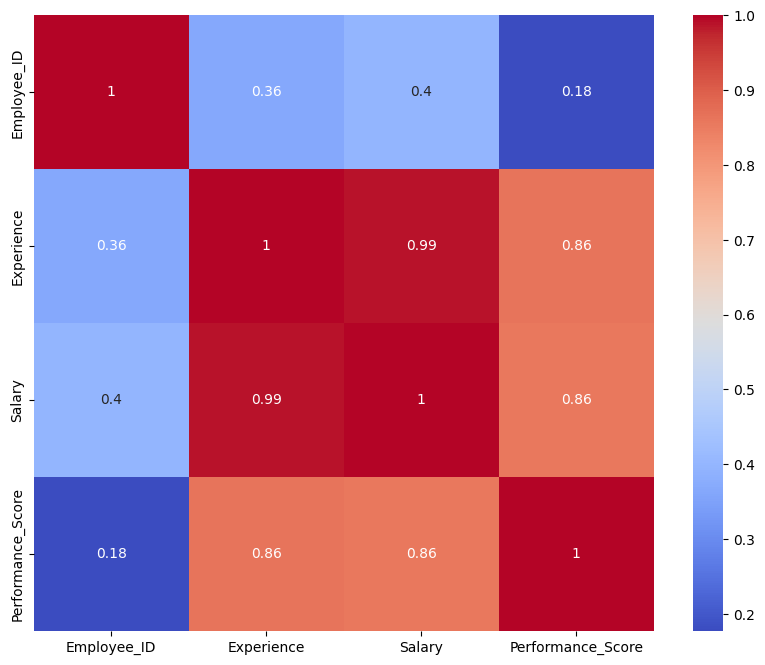

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

In [29]:
df.to_csv("cleaned_dataset.csv", index=False)

Phase 4: Insights for ML Modeling

Add a final Markdown section:

Insights for ML Modeling
1. High Correlation Features

Example:

Salary and Experience show a strong positive correlation (0.88).
These variables may introduce multicollinearity.
2. Outlier Columns

Example:

Salary contains extreme upper-end outliers.
Age contains a few unusual values.

3. Structural Changes Performed Removed duplicate rows. Converted object columns to numeric data types. Handled missing values using median and mode. Standardized dataset structure. Ensured no null values remain.

4. ML Readiness Verification

In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 25 entries, 0 to 25
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        25 non-null     int64  
 1   Age                25 non-null     str    
 2   Gender             25 non-null     str    
 3   Department         25 non-null     str    
 4   Experience         25 non-null     float64
 5   Salary             25 non-null     float64
 6   Performance_Score  25 non-null     float64
dtypes: float64(3), int64(1), str(3)
memory usage: 1.6 KB


In [31]:
df.isnull().sum().sum()

np.int64(0)

In [32]:
df.duplicated().sum()

np.int64(0)